In [1]:
import os
print(os.getcwd())
os.chdir("C:/team projects/flow/01_notebooks/01_preprocessing/visualization")
print(os.getcwd())
from dotenv import load_dotenv
load_dotenv()

C:\python
C:\team projects\flow\01_notebooks\01_preprocessing\visualization


True

# 5단계 검색 방식 성능 비교 시각화
BM25 / Dense / RRF / HyDE 4가지 방식 비교

In [2]:
import sys, os

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))  # 01_preprocessing
sys.path.append(BASE_DIR)

print("BASE_DIR:", BASE_DIR)  # 확인용

from minha_retriever import CosmeticRetriever, load_faiss_auto
from minha_evaluator import Evaluator

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글
# matplotlib.rcParams['font.family'] = 'AppleGothic'  # Mac 한글
matplotlib.rcParams['axes.unicode_minus'] = False

FAISS_PATH = '../../../00_data/02_processed/faiss_index_preset3'

BASE_DIR: C:\team projects\flow\01_notebooks\01_preprocessing


## 1. 데이터 및 Retriever 초기화

In [3]:
faiss_index, documents = load_faiss_auto(FAISS_PATH)
retriever = CosmeticRetriever(faiss_index=faiss_index, documents=documents, top_k=5)
print('초기화 완료')

[INFO] FAISS 차원: 1536d
[INFO] Document 41797개 로드 완료
초기화 완료


## 2. 테스트 쿼리 + 정답 설정

In [4]:
# 쿼리와 정답 성분명(ingredient_ko) 목록
TEST_CASES = [
    {
        'query': '나이아신아마이드 안전한가요?',
        'relevant': ['나이아신아마이드', '니코틴아마이드', '비타민 B3']
    },
    {
        'query': '건성 피부에 좋은 성분',
        'relevant': ['세라마이드', '히알루론산', '판테놀']
    },
    {
        'query': '레티놀 부작용',
        'relevant': ['레티놀', '레티닐팔미테이트', '레틴산']
    },
]
print(f'테스트 쿼리 {len(TEST_CASES)}개 준비 완료')

테스트 쿼리 3개 준비 완료


## 3. 4가지 방법 검색 + 평가 지표 계산

In [5]:
METHODS = ['bm25', 'dense', 'rrf', 'hyde']
fn_map  = {
    'bm25':  retriever.search_bm25,
    'dense': retriever.search_dense,
    'rrf':   retriever.search_rrf,
    'hyde':  retriever.search_hyde,
}

all_records = []

for tc in TEST_CASES:
    query    = tc['query']
    relevant = tc['relevant']
    evaluator = Evaluator(relevant_ids=relevant)
    print(f"\n쿼리: '{query}'")

    for m in METHODS:
        resp   = fn_map[m](query)
        result = evaluator.evaluate(resp)
        all_records.append({
            'query':      query,
            'method':     m.upper(),
            'Precision@3': result.precision_at_3,
            'Recall@3':   result.recall_at_3,
            'MRR':        result.mrr,
            'NDCG@3':     result.ndcg_at_3,
            'latency_ms': resp.latency_ms,
        })
        print(f'  [{m.upper():<5}] P@3={result.precision_at_3:.2f} R@3={result.recall_at_3:.2f} MRR={result.mrr:.2f} NDCG@3={result.ndcg_at_3:.2f} ({resp.latency_ms:.0f}ms)')

df = pd.DataFrame(all_records)
print('\n완료!')


쿼리: '나이아신아마이드 안전한가요?'
  [BM25 ] P@3=0.67 R@3=0.67 MRR=1.00 NDCG@3=0.77 (41ms)
  [DENSE] P@3=0.33 R@3=0.33 MRR=1.00 NDCG@3=0.47 (1507ms)
  [RRF  ] P@3=1.00 R@3=1.00 MRR=1.00 NDCG@3=1.00 (407ms)

  [HyDE 생성 성분명] ['나이아신아마이드', '판테놀', '알란토인', '세라마이드', '알로에베라잎추출물']
  [HyDE 검색결과]
    1. 알란토인 (RRF=0.0320)
    2. 알로에베라잎추출물 (RRF=0.0302)
    3. 나이아신아마이드 (RRF=0.0164)
    4. 판테놀 (RRF=0.0164)
    5. 알란토인 (RRF=0.0164)
  [HYDE ] P@3=0.33 R@3=0.33 MRR=0.33 NDCG@3=0.23 (2341ms)

쿼리: '건성 피부에 좋은 성분'
  [BM25 ] P@3=0.00 R@3=0.00 MRR=0.00 NDCG@3=0.00 (46ms)
  [DENSE] P@3=0.00 R@3=0.00 MRR=0.00 NDCG@3=0.00 (185ms)
  [RRF  ] P@3=0.00 R@3=0.00 MRR=0.00 NDCG@3=0.00 (325ms)

  [HyDE 생성 성분명] ['세라마이드', '히알루론산', '글리세린', '판테놀', '쉐어버터']
  [HyDE 검색결과]
    1. 세라마이드 (RRF=0.0164)
    2. 소듐카복시메틸하이알루로네이트 (RRF=0.0164)
    3. 하이알루로니다아제 (RRF=0.0164)
    4. 글리세린 (RRF=0.0164)
    5. 판테놀 (RRF=0.0164)
  [HYDE ] P@3=0.33 R@3=0.33 MRR=1.00 NDCG@3=0.47 (1858ms)

쿼리: '레티놀 부작용'
  [BM25 ] P@3=0.33 R@3=0.33 MRR=1.00 NDCG@3=0.47 (32ms)
 

## 4. 평균 지표 테이블

In [6]:
metrics = ['Precision@3', 'Recall@3', 'MRR', 'NDCG@3', 'latency_ms']
avg_df  = df.groupby('method')[metrics].mean().round(4)
avg_df.columns.name = None
avg_df.index.name   = '방법'
avg_df

,Precision@3,Recall@3,MRR,NDCG@3,latency_ms
방법,,,,,
BM25,0.3333,0.3333,0.6667,0.4116,39.5721
DENSE,0.2222,0.2222,0.4444,0.2346,655.6880
HYDE,0.3333,0.3333,0.6111,0.3333,2233.5645
RRF,0.5556,0.5556,0.6667,0.5885,355.6474


## 5. 차트 시각화

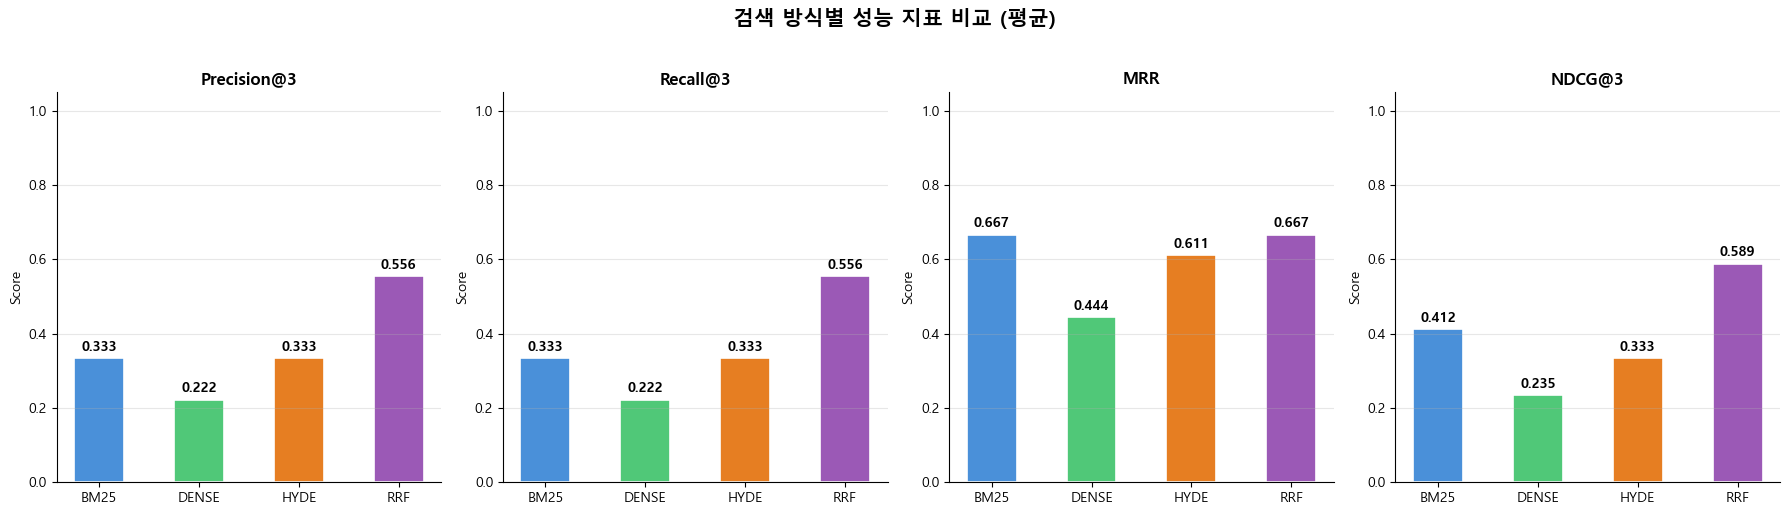

저장: stage5_metrics.png


In [7]:
COLORS  = {'BM25': '#4A90D9', 'DENSE': '#50C878', 'RRF': '#9B59B6', 'HYDE': '#E67E22'}
METRICS = ['Precision@3', 'Recall@3', 'MRR', 'NDCG@3']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('검색 방식별 성능 지표 비교 (평균)', fontsize=15, fontweight='bold', y=1.02)

for ax, metric in zip(axes, METRICS):
    methods = avg_df.index.tolist()
    values  = avg_df[metric].tolist()
    colors  = [COLORS.get(m, '#95A5A6') for m in methods]

    bars = ax.bar(methods, values, color=colors, width=0.5, edgecolor='white', linewidth=1.2)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{val:.3f}',
            ha='center', fontsize=10, fontweight='bold'
        )

plt.tight_layout()
plt.savefig('stage5_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: stage5_metrics.png')

## 6. 응답시간 비교

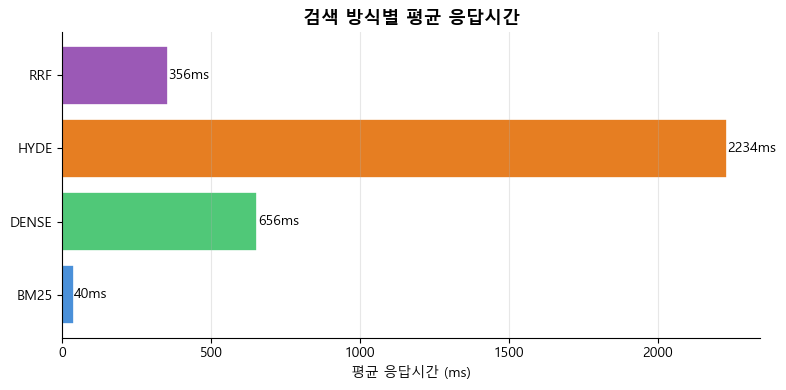

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

methods  = avg_df.index.tolist()
latency  = avg_df['latency_ms'].tolist()
colors   = [COLORS.get(m, '#95A5A6') for m in methods]

bars = ax.barh(methods, latency, color=colors, edgecolor='white', linewidth=1.2)
ax.set_xlabel('평균 응답시간 (ms)')
ax.set_title('검색 방식별 평균 응답시간', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, latency):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}ms', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('stage5_latency.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 쿼리별 점수 히트맵

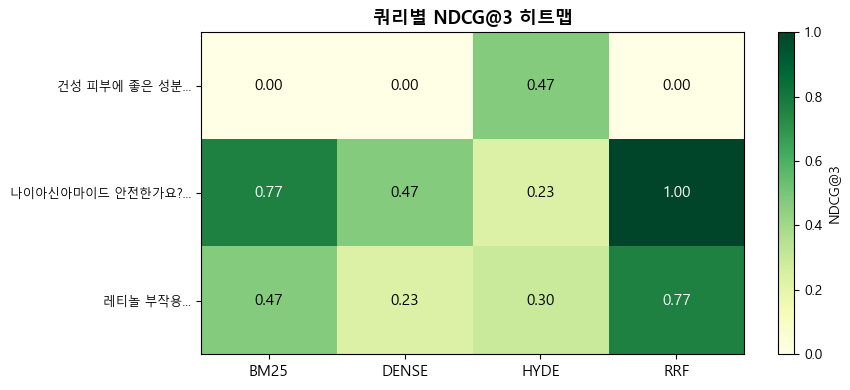

In [9]:
import numpy as np

pivot = df.pivot_table(index='query', columns='method', values='NDCG@3')

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([q[:15] + '...' for q in pivot.index], fontsize=9)
ax.set_title('쿼리별 NDCG@3 히트맵', fontsize=13, fontweight='bold')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=11, color='black' if val < 0.6 else 'white')

plt.colorbar(im, ax=ax, label='NDCG@3')
plt.tight_layout()
plt.savefig('stage5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()